<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


This exercise, will focus on the visualization of data. The dataset will be provided through an RDBMS, and will need to use SQL queries to extract the required data.


## Objectives


In this lab, will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-09-05 01:53:20--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  8.31MB/s    in 21s     

2026-09-05 01:53:41 (9.66 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 170.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 194.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 160.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 177.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [8]:
!pip install matplotlib

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Connect to the SQLite database


In [6]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [10]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

**Demo 2: List all tables**


In [11]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [12]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


**1.1 Histogram of `CompTotal` (Total Compensation)**


### 1. Visualizing the distribution of data (Histograms)


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


       CompTotal  ResponseId
72     2040000.0          73
374      28000.0         375
379      85000.0         380
385      50000.0         386
389     110000.0         390
...          ...         ...
65396    36000.0       65397
65401    40000.0       65402
65408    61000.0       65409
65412    58000.0       65413
65431    55000.0       65432

[33740 rows x 2 columns]
14354    1.000000e+150
34278     1.000000e+65
17374     1.000000e+53
8814      1.000000e+44
20037     8.000000e+27
Name: CompTotal, dtype: float64
NEW DATA         CompTotal  ResponseId
72     2040000.0          73
374      28000.0         375
379      85000.0         380
385      50000.0         386
389     110000.0         390
...          ...         ...
65396    36000.0       65397
65401    40000.0       65402
65408    61000.0       65409
65412    58000.0       65413
65431    55000.0       65432

[32086 rows x 2 columns]
CompTotal     float64
ResponseId      int64
dtype: object

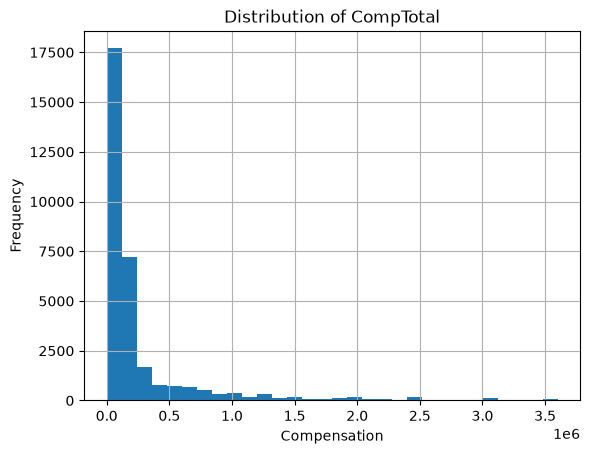

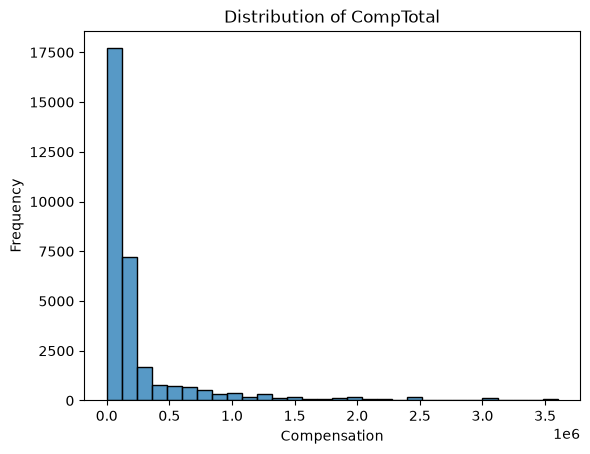

In [13]:
comp_total ="select CompTotal , ResponseId from main"
comp_data = pd.read_sql_query(comp_total, conn).dropna()
print (comp_data)
print(comp_data["CompTotal"].nlargest(5))

upper = comp_data["CompTotal"].quantile(.95)
comp_data_new= comp_data[comp_data["CompTotal"] <= upper]
print("NEW DATA ",comp_data_new)

print(comp_data_new.dtypes)

#matplotlib
comp_data_new.hist(column="CompTotal", bins = 30)
plt.title("Distribution of CompTotal")
plt.xlabel("Compensation")
plt.ylabel("Frequency")
plt.show()

#seaborn
sns.histplot(data = comp_data_new, x = "CompTotal", bins = 30)
plt.title("Distribution of CompTotal")
plt.xlabel("Compensation")
plt.ylabel("Frequency")
plt.show()



**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


       YearsCodePro
1              17.0
2              27.0
6               7.0
9              11.0
11             25.0
...             ...
65428           7.0
65431          24.0
65432           3.0
65434           5.0
65435           2.0

[51610 rows x 1 columns]


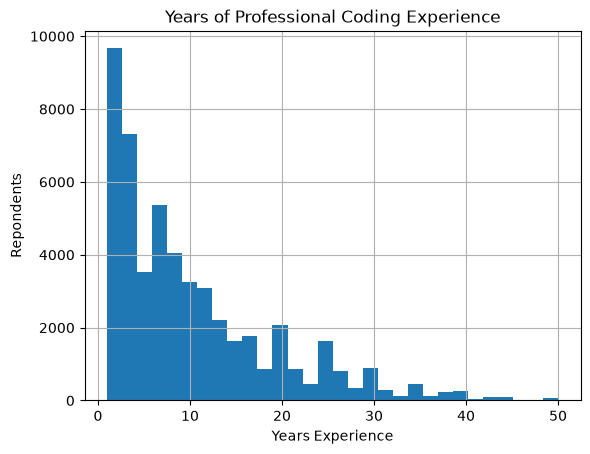

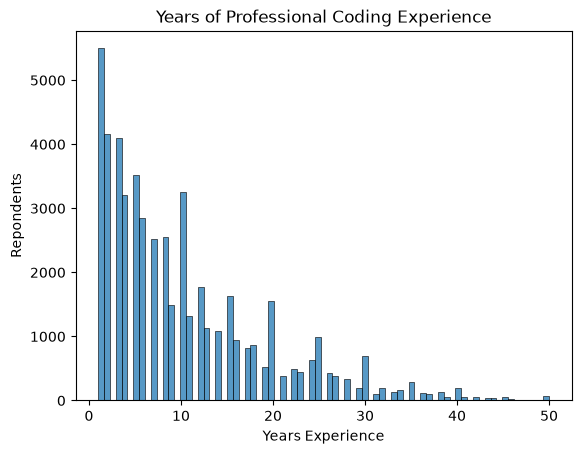

In [13]:
years_code = "select YearsCodePro from main"
years_code_data = pd.read_sql_query(years_code, conn).dropna()
years_code_data["YearsCodePro"] = years_code_data["YearsCodePro"].replace({"Less than 1 year":"1", "More than 50 years":"50"}).astype(float)

print(years_code_data)

years_code_data.hist(column= "YearsCodePro",  bins=30)
plt.title("Years of Professional Coding Experience")
plt.xlabel("Years Experience")
plt.ylabel("Repondents")
plt.show()

sns.histplot(data = years_code_data, x= "YearsCodePro")
plt.title("Years of Professional Coding Experience")
plt.xlabel("Years Experience")
plt.ylabel("Repondents")
plt.show()



### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


       CompTotal              Age
72     2040000.0  18-24 years old
374      28000.0  25-34 years old
379      85000.0  35-44 years old
385      50000.0  35-44 years old
389     110000.0  25-34 years old
...          ...              ...
65396    36000.0  18-24 years old
65401    40000.0  25-34 years old
65408    61000.0  25-34 years old
65412    58000.0  35-44 years old
65431    55000.0  45-54 years old

[33740 rows x 2 columns]

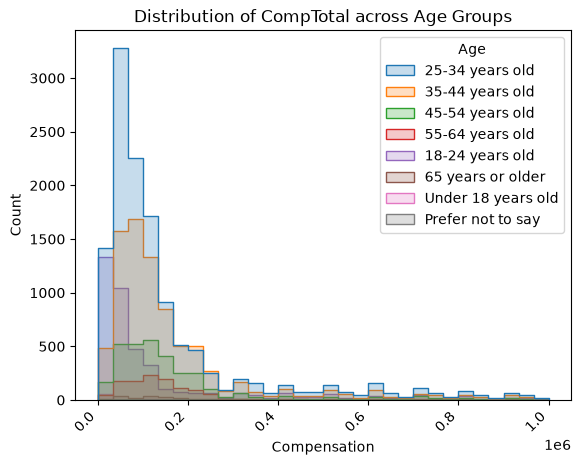

In [16]:
comp_age = "select CompTotal,Age from main "
comp_age_data = pd.read_sql_query(comp_age, conn).dropna()
print(comp_age_data)

comp_age_filtered = comp_age_data[
    comp_age_data["CompTotal"] < 1_000_000
]
#comp_age_group = comp_age_data.groupby("Age")["CompTotal"].median()
#print(comp_age_group)

#seaborn
sns.histplot(data = comp_age_filtered, x = "CompTotal", hue="Age", bins =30, element ="step", common_norm= False)
plt.xticks(rotation = 45, ha = "right")
plt.title("Distribution of CompTotal across Age Groups")
plt.xlabel("Compensation")
plt.ylabel("Count")
plt.show()


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


                TimeSearching                 Age
27671     30-60 minutes a day     18-24 years old
16678    60-120 minutes a day     18-24 years old
16674  Over 120 minutes a day     18-24 years old
16673     15-30 minutes a day     18-24 years old
16672     15-30 minutes a day     18-24 years old
...                       ...                 ...
42107     30-60 minutes a day  Under 18 years old
17136     30-60 minutes a day  Under 18 years old
35931     15-30 minutes a day  Under 18 years old
14676     15-30 minutes a day  Under 18 years old
31065     30-60 minutes a day  Under 18 years old

[28911 rows x 2 columns]


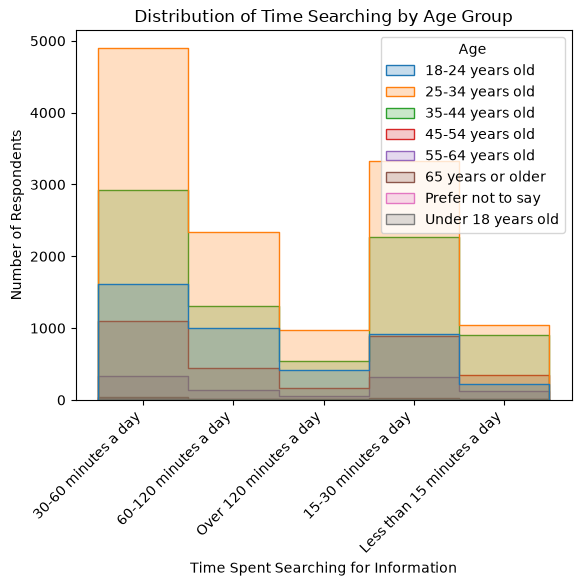

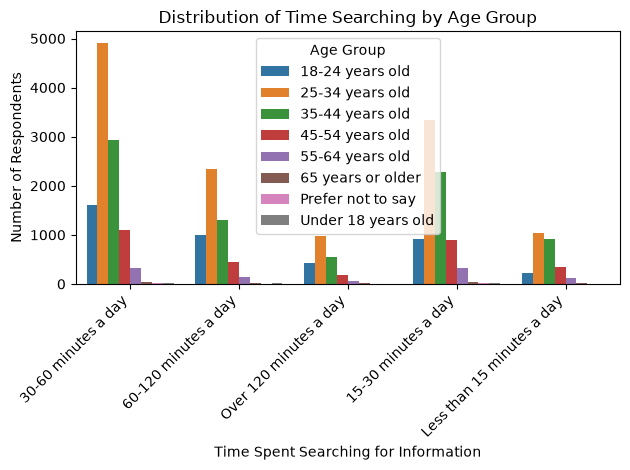

                 TimeSearching                 Age  Count
0          15-30 minutes a day     18-24 years old    922
1          15-30 minutes a day     25-34 years old   3332
2          15-30 minutes a day     35-44 years old   2275
3          15-30 minutes a day     45-54 years old    888
4          15-30 minutes a day     55-64 years old    325
5          15-30 minutes a day   65 years or older     34
6          15-30 minutes a day   Prefer not to say     11
7          15-30 minutes a day  Under 18 years old     18
8          30-60 minutes a day     18-24 years old   1614
9          30-60 minutes a day     25-34 years old   4901
10         30-60 minutes a day     35-44 years old   2924
11         30-60 minutes a day     45-54 years old   1096
12         30-60 minutes a day     55-64 years old    331
13         30-60 minutes a day   65 years or older     45
14         30-60 minutes a day   Prefer not to say     12
15         30-60 minutes a day  Under 18 years old     28
16        60-1

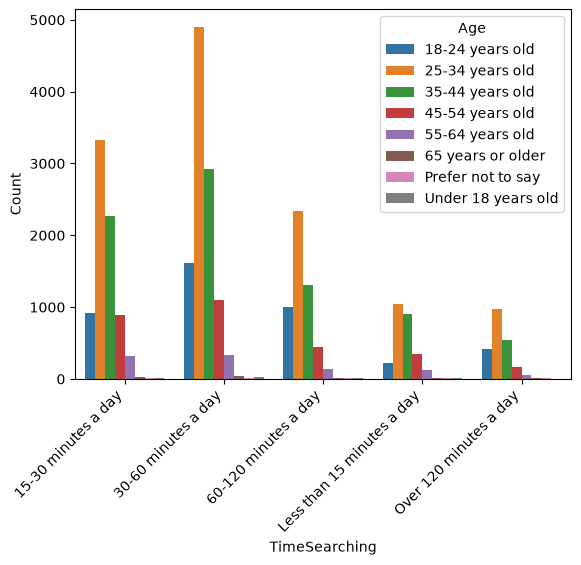

In [17]:
time_age = "select TimeSearching, Age from main"
time_age_data = pd.read_sql_query(time_age, conn).dropna()
print(time_age_data)

sns.histplot(data=time_age_data, x= "TimeSearching", hue= "Age", element= "step",bins = 30)
plt.title("Distribution of Time Searching by Age Group")
plt.xlabel("Time Spent Searching for Information")
plt.ylabel("Number of Respondents")
plt.xticks(rotation = 45, ha = "right")
plt.show()

# countplot
sns.countplot(
    data=time_age_data,
    x="TimeSearching",
    hue="Age"
)

plt.title("Distribution of Time Searching by Age Group")
plt.xlabel("Time Spent Searching for Information")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

time_age_counts = (
    time_age_data
    .groupby(["TimeSearching", "Age"])
    .size()
    .reset_index(name="Count")
)

print(time_age_counts)

sns.barplot(data=time_age_counts,
    x="TimeSearching",
    hue="Age", y= "Count"
)
plt.xticks(rotation = 45, ha="right")
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


                                  DatabaseWantToWorkWith
1                                             PostgreSQL
2                             Firebase Realtime Database
3                               MongoDB;MySQL;PostgreSQL
4                                      PostgreSQL;SQLite
5                                        Cloud Firestore
...                                                  ...
65421                                           Dynamodb
65427  BigQuery;Cassandra;Databricks SQL;DuckDB;Elast...
65431                     Elasticsearch;PostgreSQL;Redis
65435                                  PostgreSQL;SQLite
65436                           MongoDB;MySQL;PostgreSQL

[42558 rows x 1 columns]
DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

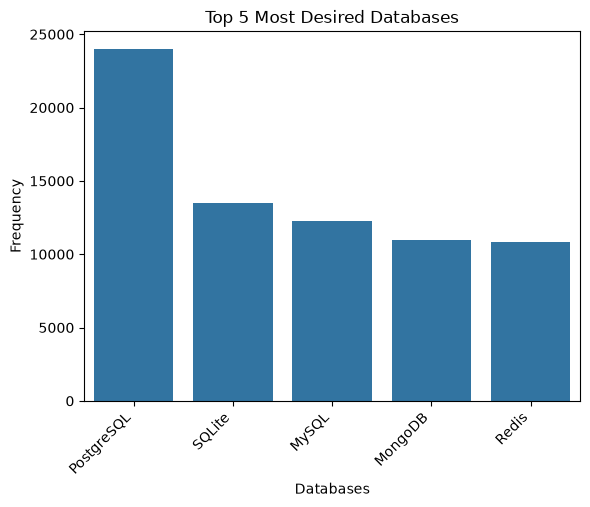

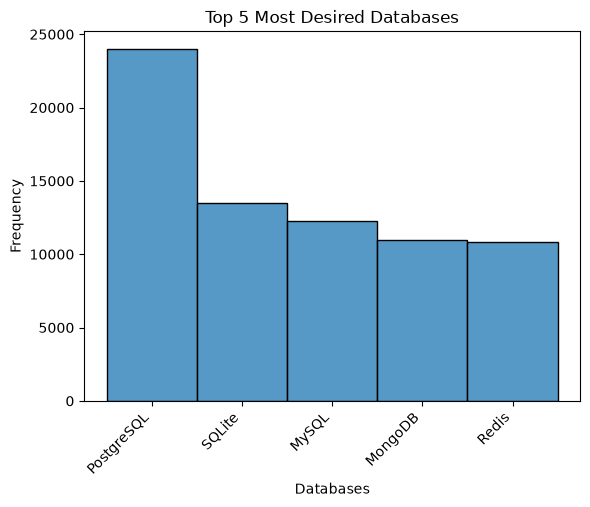

In [17]:
most_desired = "select DatabaseWantToWorkWith from main"
most_desired_data = pd.read_sql_query(most_desired, conn).dropna()
print(most_desired_data)
most_desired_data = most_desired_data["DatabaseWantToWorkWith"].str.split(";").explode().str.strip().value_counts().head()
print (most_desired_data)

sns.barplot(x= most_desired_data.index, y = most_desired_data.values)
plt.title("Top 5 Most Desired Databases")
plt.xlabel("Databases")
plt.ylabel("Frequency")
plt.xticks(rotation = 45, ha = "right")
plt.show()

sns.histplot(
    x=most_desired_data.index,
    weights=most_desired_data.values
)
plt.title("Top 5 Most Desired Databases")
plt.xlabel("Databases")
plt.ylabel("Frequency")
plt.xticks(rotation = 45, ha = "right")
plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

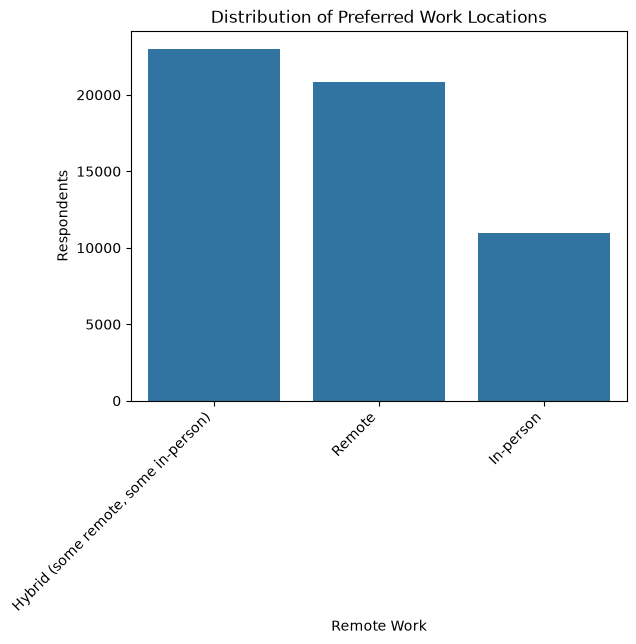

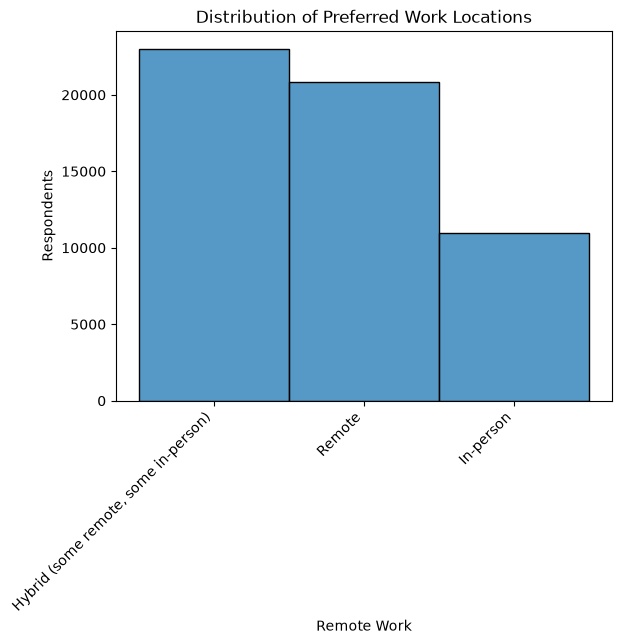

In [18]:
remote_work = "select RemoteWork from main"
remote_work_data = pd.read_sql_query(remote_work, conn).dropna()
remote_work_data= remote_work_data["RemoteWork"].value_counts()
print (remote_work_data)

#bar 
sns.barplot(x= remote_work_data.index, y = remote_work_data.values)
plt.title("Distribution of Preferred Work Locations")
plt.xlabel("Remote Work")
plt.ylabel("Respondents")
plt.xticks(rotation = 45, ha = "right")
plt.show()

#hist
sns.histplot(x= remote_work_data.index, weights= remote_work_data.values)
plt.title("Distribution of Preferred Work Locations")
plt.xlabel("Remote Work")
plt.ylabel("Respondents")
plt.xticks(rotation = 45, ha = "right")
plt.show()




### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Age
45-54 years old    130000.0
55-64 years old    135000.0
Name: CompTotal, dtype: float64


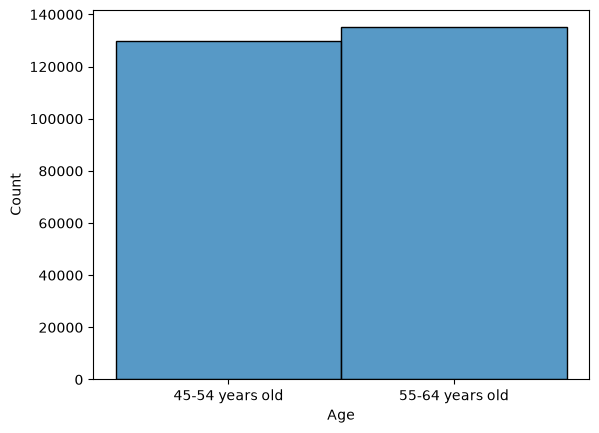

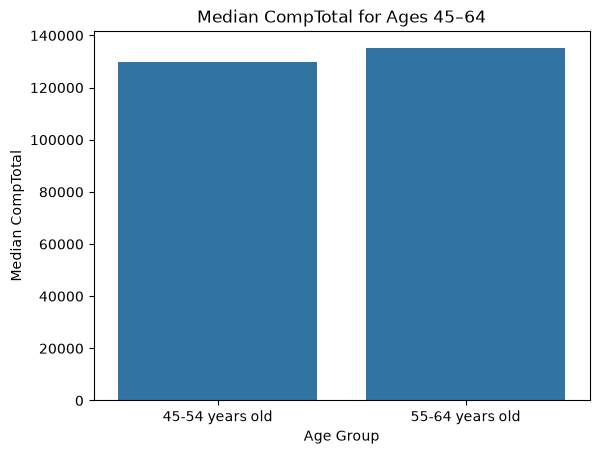

      CompTotal              Age
69      95000.0  45-54 years old
71     195000.0  45-54 years old
73      54000.0  55-64 years old
76     145000.0  45-54 years old
78      80000.0  55-64 years old
...         ...              ...
8799    40000.0  45-54 years old
8807   250000.0  45-54 years old
8811   250000.0  45-54 years old
8812   157000.0  45-54 years old
8823    55000.0  45-54 years old

[4795 rows x 2 columns]


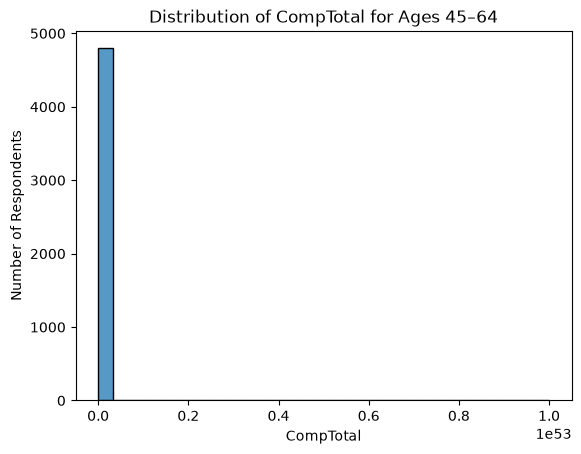

In [107]:
med_comp = "select CompTotal, Age from main where Age in ('45-54 years old', '55-64 years old')"
med_comp_data = pd.read_sql_query(med_comp, conn).dropna()
med_data = med_comp_data.groupby("Age")["CompTotal"].median()
print(med_data)

sns.histplot(x = med_data.index, weights= med_data.values)
plt.show()


sns.barplot(x=med_data.index, y=med_data.values)
plt.xlabel("Age Group")
plt.ylabel("Median CompTotal")
plt.title("Median CompTotal for Ages 45–64")
plt.show()

#count by respondens with selected age
med_comp_data = pd.read_sql_query(med_comp, conn).dropna(subset=["CompTotal"])
print(med_comp_data)
sns.histplot(data=med_comp_data, x="CompTotal", bins=30)

plt.xlabel("CompTotal")
plt.ylabel("Number of Respondents")
plt.title("Distribution of CompTotal for Ages 45–64")
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


       JobSat  YearsCodePro
12        8.0          12.0
15        5.0          27.0
18       10.0          10.0
20        6.0           1.0
22        9.0          18.0
...       ...           ...
65178     8.0          17.0
65241     5.0          10.0
65265     8.0           2.0
65351     8.0           7.0
65412     8.0          18.0

[28356 rows x 2 columns]


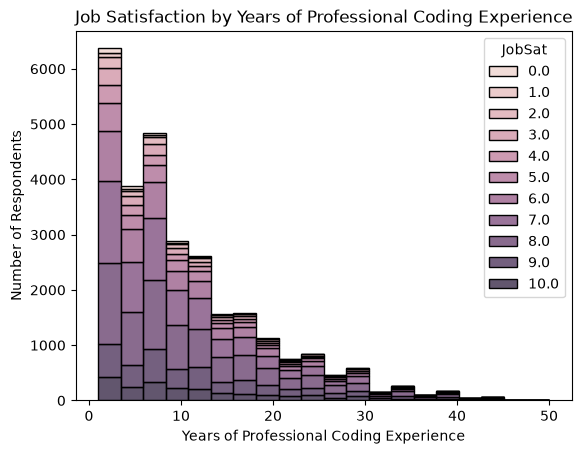

In [142]:
jobsat_pro = "select JobSat, YearsCodePro from main"
job_pro_data = pd.read_sql_query(jobsat_pro, conn).dropna()
job_pro_data["YearsCodePro"]= job_pro_data["YearsCodePro"].str.strip().replace({"Less than 1 year": 1, "More than 50 years":50}).astype(float)
print(job_pro_data)
sns.histplot(data = job_pro_data, x="YearsCodePro", hue= "JobSat", bins = 20, multiple= "stack")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")
plt.title("Job Satisfaction by Years of Professional Coding Experience")
plt.show()

### Final step: Close the database connection


In [ ]:
conn.close()

### Summary


This exercise, used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


Copyright © IBM Corporation. All rights reserved.
